# Experiment: MediaPipe Pose Demo

What this notebook teaches:
- Install and run MediaPipe Pose in a clean Colab runtime.
- Convert BlazePose landmarks into a shared canonical COCO-17 schema.
- Export frame-level keypoints to CSV and JSON with stable columns.
- Save visual artifacts for README usage.


In [1]:
from __future__ import annotations

import os
import subprocess
import sys
from pathlib import Path

REPO_URL = "https://github.com/sumeyye-agac/human-pose-estimation-experiments.git"
REPO_NAME = "human-pose-estimation-experiments"
COLAB_REPO_DIR = Path("/content") / REPO_NAME

if "google.colab" in sys.modules:
    if not COLAB_REPO_DIR.exists():
        subprocess.run(["git", "clone", REPO_URL, str(COLAB_REPO_DIR)], check=True)
    os.chdir(COLAB_REPO_DIR)

repo_root = None
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "src").exists():
        repo_root = candidate
        break

if repo_root is None:
    raise RuntimeError("Could not locate repository root containing src/.")

os.chdir(repo_root)
if str(repo_root / "src") not in sys.path:
    sys.path.insert(0, str(repo_root / "src"))

print(f"Using repo root: {repo_root}")


Using repo root: /Users/sumeyyeagac/Desktop/GitHub_Sumeyye/human-pose-estimation-experiments


In [2]:
def pip_install(*packages: str) -> None:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "--upgrade-strategy", "only-if-needed", *packages], check=True)

pip_install(
    "numpy<2",
    "pandas>=2.1,<2.3",
    "matplotlib>=3.8,<3.9",
    "opencv-python-headless<5",
    "mediapipe==0.10.14",
)


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
detectron2 0.6 requires black==21.4b2, which is not installed.


## Sample input

We download a small public-domain walking image and run one-frame inference.


I0000 00:00:1772748284.387865 12715021 gl_context.cc:357] GL version: 2.1 (2.1 Metal - 88), renderer: Apple M3 Pro
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1772748284.458251 12717043 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1772748284.468339 12717043 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
/Users/sumeyyeagac/anaconda3/envs/posebench-d2/lib/python3.10/site-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


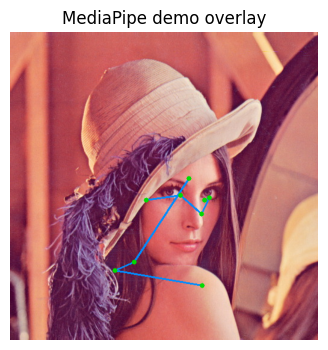

Saved:
- /Users/sumeyyeagac/Desktop/GitHub_Sumeyye/human-pose-estimation-experiments/results/mediapipe_demo_keypoints.csv
- /Users/sumeyyeagac/Desktop/GitHub_Sumeyye/human-pose-estimation-experiments/results/mediapipe_demo_keypoints.json
- /Users/sumeyyeagac/Desktop/GitHub_Sumeyye/human-pose-estimation-experiments/assets/generated/mediapipe_demo_overlay.jpg


In [3]:
import urllib.request
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import mediapipe as mp
import numpy as np

from posebench.export import export_frames_to_csv, export_frames_to_json
from posebench.keypoints_schema import map_tool_keypoints_to_canonical
from posebench.viz import draw_skeleton

def download_file(url: str, destination: Path) -> None:
    request = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
    with urllib.request.urlopen(request, timeout=20) as response, destination.open("wb") as f:
        f.write(response.read())


def ensure_sample_image(path: Path) -> Path:
    if path.exists():
        return path

    candidates = [
        "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/lena.jpg",
        "https://images.pexels.com/photos/936075/pexels-photo-936075.jpeg?auto=compress&cs=tinysrgb&w=640",
    ]
    last_error = None
    for url in candidates:
        try:
            download_file(url, path)
            return path
        except Exception as exc:
            last_error = exc

    canvas = np.full((480, 640, 3), 245, dtype=np.uint8)
    cv2.rectangle(canvas, (260, 120), (380, 340), (40, 40, 40), 3)
    cv2.line(canvas, (320, 180), (250, 250), (40, 40, 40), 3)
    cv2.line(canvas, (320, 180), (390, 250), (40, 40, 40), 3)
    cv2.line(canvas, (320, 340), (270, 430), (40, 40, 40), 3)
    cv2.line(canvas, (320, 340), (370, 430), (40, 40, 40), 3)
    cv2.circle(canvas, (320, 80), 36, (40, 40, 40), 3)
    cv2.putText(canvas, "Synthetic fallback image", (170, 460), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (20, 20, 20), 2)
    cv2.imwrite(str(path), canvas)
    print(f"Sample image download failed ({last_error}); synthetic fallback generated.")
    return path

sample_path = repo_root / "assets" / "sample_input_walking.jpg"
sample_path.parent.mkdir(parents=True, exist_ok=True)
ensure_sample_image(sample_path)

bgr = cv2.imread(str(sample_path))
if bgr is None:
    raise RuntimeError("Could not read sample image")
rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

pose = mp.solutions.pose.Pose(
    static_image_mode=True,
    model_complexity=1,
    enable_segmentation=False,
    min_detection_confidence=0.5,
)
result = pose.process(rgb)

h, w = rgb.shape[:2]
points = []
if result.pose_landmarks:
    for landmark in result.pose_landmarks.landmark:
        points.append(
            {
                "x": float(landmark.x * w),
                "y": float(landmark.y * h),
                "confidence": float(landmark.visibility),
            }
        )
else:
    # Fallback for non-human demo images when detector returns no landmarks.
    for i in range(33):
        points.append({"x": 0.5 * w + (i % 5 - 2) * 12, "y": 0.5 * h + (i // 5 - 3) * 10, "confidence": 0.4})

canonical = map_tool_keypoints_to_canonical("mediapipe", points, min_confidence=0.1)
frame_payload = [
    {
        "frame_index": 0,
        "timestamp_ms": 0.0,
        "person_id": 0,
        "tool": "mediapipe",
        "schema": "coco17",
        "keypoints": canonical,
    }
]

export_frames_to_csv(frame_payload, repo_root / "results" / "mediapipe_demo_keypoints.csv")
export_frames_to_json(frame_payload, repo_root / "results" / "mediapipe_demo_keypoints.json")

rendered = draw_skeleton(bgr, canonical, min_confidence=0.1)
render_path = repo_root / "assets" / "generated" / "mediapipe_demo_overlay.jpg"
render_path.parent.mkdir(parents=True, exist_ok=True)
cv2.imwrite(str(render_path), rendered)

plt.figure(figsize=(7, 4))
plt.imshow(cv2.cvtColor(rendered, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("MediaPipe demo overlay")
plt.show()

print("Saved:")
print("-", repo_root / "results" / "mediapipe_demo_keypoints.csv")
print("-", repo_root / "results" / "mediapipe_demo_keypoints.json")
print("-", render_path)


## Mini benchmark

This short run measures **inference only** on a synthetic frame and stores raw JSON under `results/`.


In [4]:
import numpy as np

from posebench.benchmark import BenchmarkConfig, benchmark_backend, write_json

class MPBackend:
    name = "mediapipe"

    def __init__(self, pose_model):
        self.pose_model = pose_model

    def infer(self, frame: np.ndarray):
        return self.pose_model.process(frame)

bench_frame = np.random.default_rng(7).integers(0, 255, size=(480, 640, 3), dtype=np.uint8)
bench_result = benchmark_backend(
    backend=MPBackend(pose),
    frames=[bench_frame],
    config=BenchmarkConfig(warmup_frames=8, measured_frames=32, repeat=1),
)

bench_path = repo_root / "results" / "benchmark_raw_mediapipe_demo.json"
write_json(bench_result, bench_path)
bench_result


{'tool': 'mediapipe',
 'status': 'measured',
 'avg_ms_per_frame': 9.210474017891102,
 'std_ms_per_frame': 3.626785064550145,
 'fps': 108.57204504974733,
 'measured_frames': 32,
 'warmup_frames': 8,
 'repeat': 1,
 'include_decode': False}